<a href="https://colab.research.google.com/github/Gyanendra079/ML-Internshala-Project/blob/main/ML_Project_Internshala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Part A: Property Price Prediction

## Overview

This project focuses on predicting property prices in various districts of California using
several district-level features. By building a predictive model, we aim to identify key variables
that influence housing prices and improve the accuracy of house value predictions. The
project will specifically utilize simple linear regression and multiple linear regression to
address this regression task, ensuring proper data handling and evaluation of the models.

## Problem Statement

The objective is to predict the median house value in California districts based on features
such as income, the number of rooms, geographical location, and proximity to the ocean.
Given the dataset, we will develop regression models, evaluate their performance, and
determine which model provides the best balance between predictive accuracy and
interpretability.

## Data Information
### Data Dictionary:

| Variable | Description | Type | Unit |
| :--- | :--- | :--- | :--- |
| **longitude** | Longitude of the property | FLOAT | degrees |
| **latitude** | Latitude of the property | FLOAT | degrees |
| **housing_median_age** | Median age of the houses | INT | years |
| **total_rooms** | Total number of rooms | INT | count |
| **total_bedrooms** | Total number of bedrooms | INT | count |
| **population** | Population in the area | INT | count |
| **households** | Number of households | INT | count |
| **median_income** | Median income in the area | FLOAT | - |
| **median_house_value** | Median house value | FLOAT | - |
| **ocean_proximity** | Proximity to the ocean | STRING | - |

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Read the CSV data directly into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Internsala Project and assignment/Data_file - data_file.csv')

print("DataFrame loaded successfully. Displaying the first 5 rows:")
display(df.head())

DataFrame loaded successfully. Displaying the first 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


We have to analyze the provided housing dataset to predict the `median_house_value` using regression models.
It involves various step as follows :-
* Exploratory Data Analysis (EDA),
* Handling missing values,
* Encoding categorical features,
* Splitting the data,
* Developing and evaluating both Simple and Multiple Linear Regression models Visualizing their performance
* Finally summarizing the findings and recommending the best model

## Exploratory Data Analysis (EDA) with visualizations and summary statistics.
####  Explore Data first using EDA (Exploratory Data Analysis) <p>We now proceed to doing the Exploratory Data Analysis (EDA) including descriptive statistics to understand the dataset's characteristics.

## Dataset Information
We are now understanding of the dataset's structure, data types, and identify any missing values.



In [38]:
print("Displaying basic info of the DataFrame:")
df.info()

Displaying basic info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


## Descriptive Statistics
Understanding the distribution and central tendency of numerical features,



In [39]:
print("Displaying descriptive statistics for numerical columns:")
df.describe()

Displaying descriptive statistics for numerical columns:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Visualization
Visualizing data distributions for key features

Analyze various relationships involving different features and the target variable (`median_house_value`) with the help of plots like histograms, scatter plots, and correlation matrices with proper labels and legends.

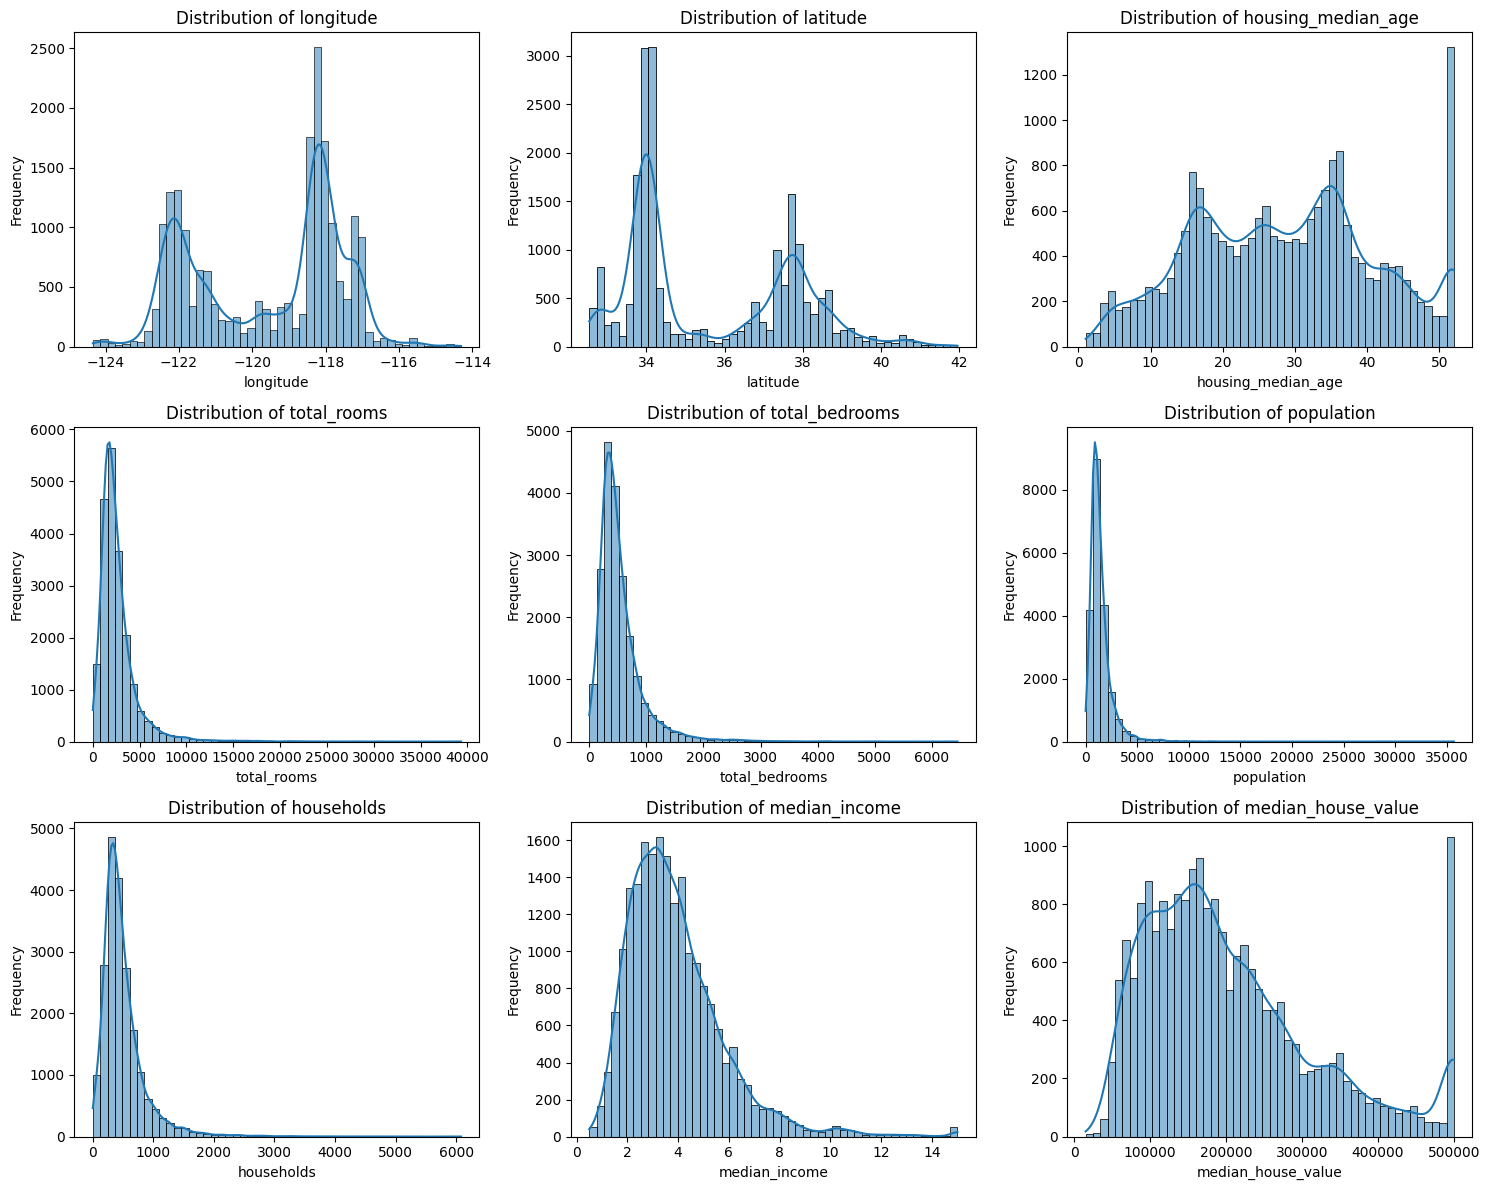

Histograms generated.


In [40]:
# Include of all numerical features
numerical_cols = df.select_dtypes(include=np.number).columns

# Determine the number of rows and columns for the subplot grid
num_cols = 3
num_rows = int(np.ceil(len(numerical_cols) / num_cols))

plt.figure(figsize=(num_cols * 5, num_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()
print("Histograms generated.")

 Key insights into the distribution of the numerical features:

* **Skewed Distributions for Many Features**: Features such as total_rooms, total_bedrooms, population, households, median_income, and median_house_value all exhibit a strong right-skewed distribution. This indicates that most districts have lower values for these attributes, with a smaller number of districts having exceptionally high values.
* **Ceiling Effect in Median House Value**: The histogram for median_house_value clearly shows a significant concentration of values at the maximum end (around $500,001), suggesting a potential ceiling or capping of these values in the dataset.
* **Geographical Concentrations**: The distributions of longitude and latitude are not uniform but show multiple peaks, which implies that the housing districts are not evenly spread across the geographical area but are concentrated in certain regions.
* **Varied Age Distribution for Housing**: housing_median_age shows a distribution with multiple peaks and a notable presence of older houses, indicating a mix of newly developed and long-established neighborhoods.

## Finding potential outliers
<p>Now visualize the spread of numerical data for which box plots are highly effective.



Box plots for numerical features to identify outliers


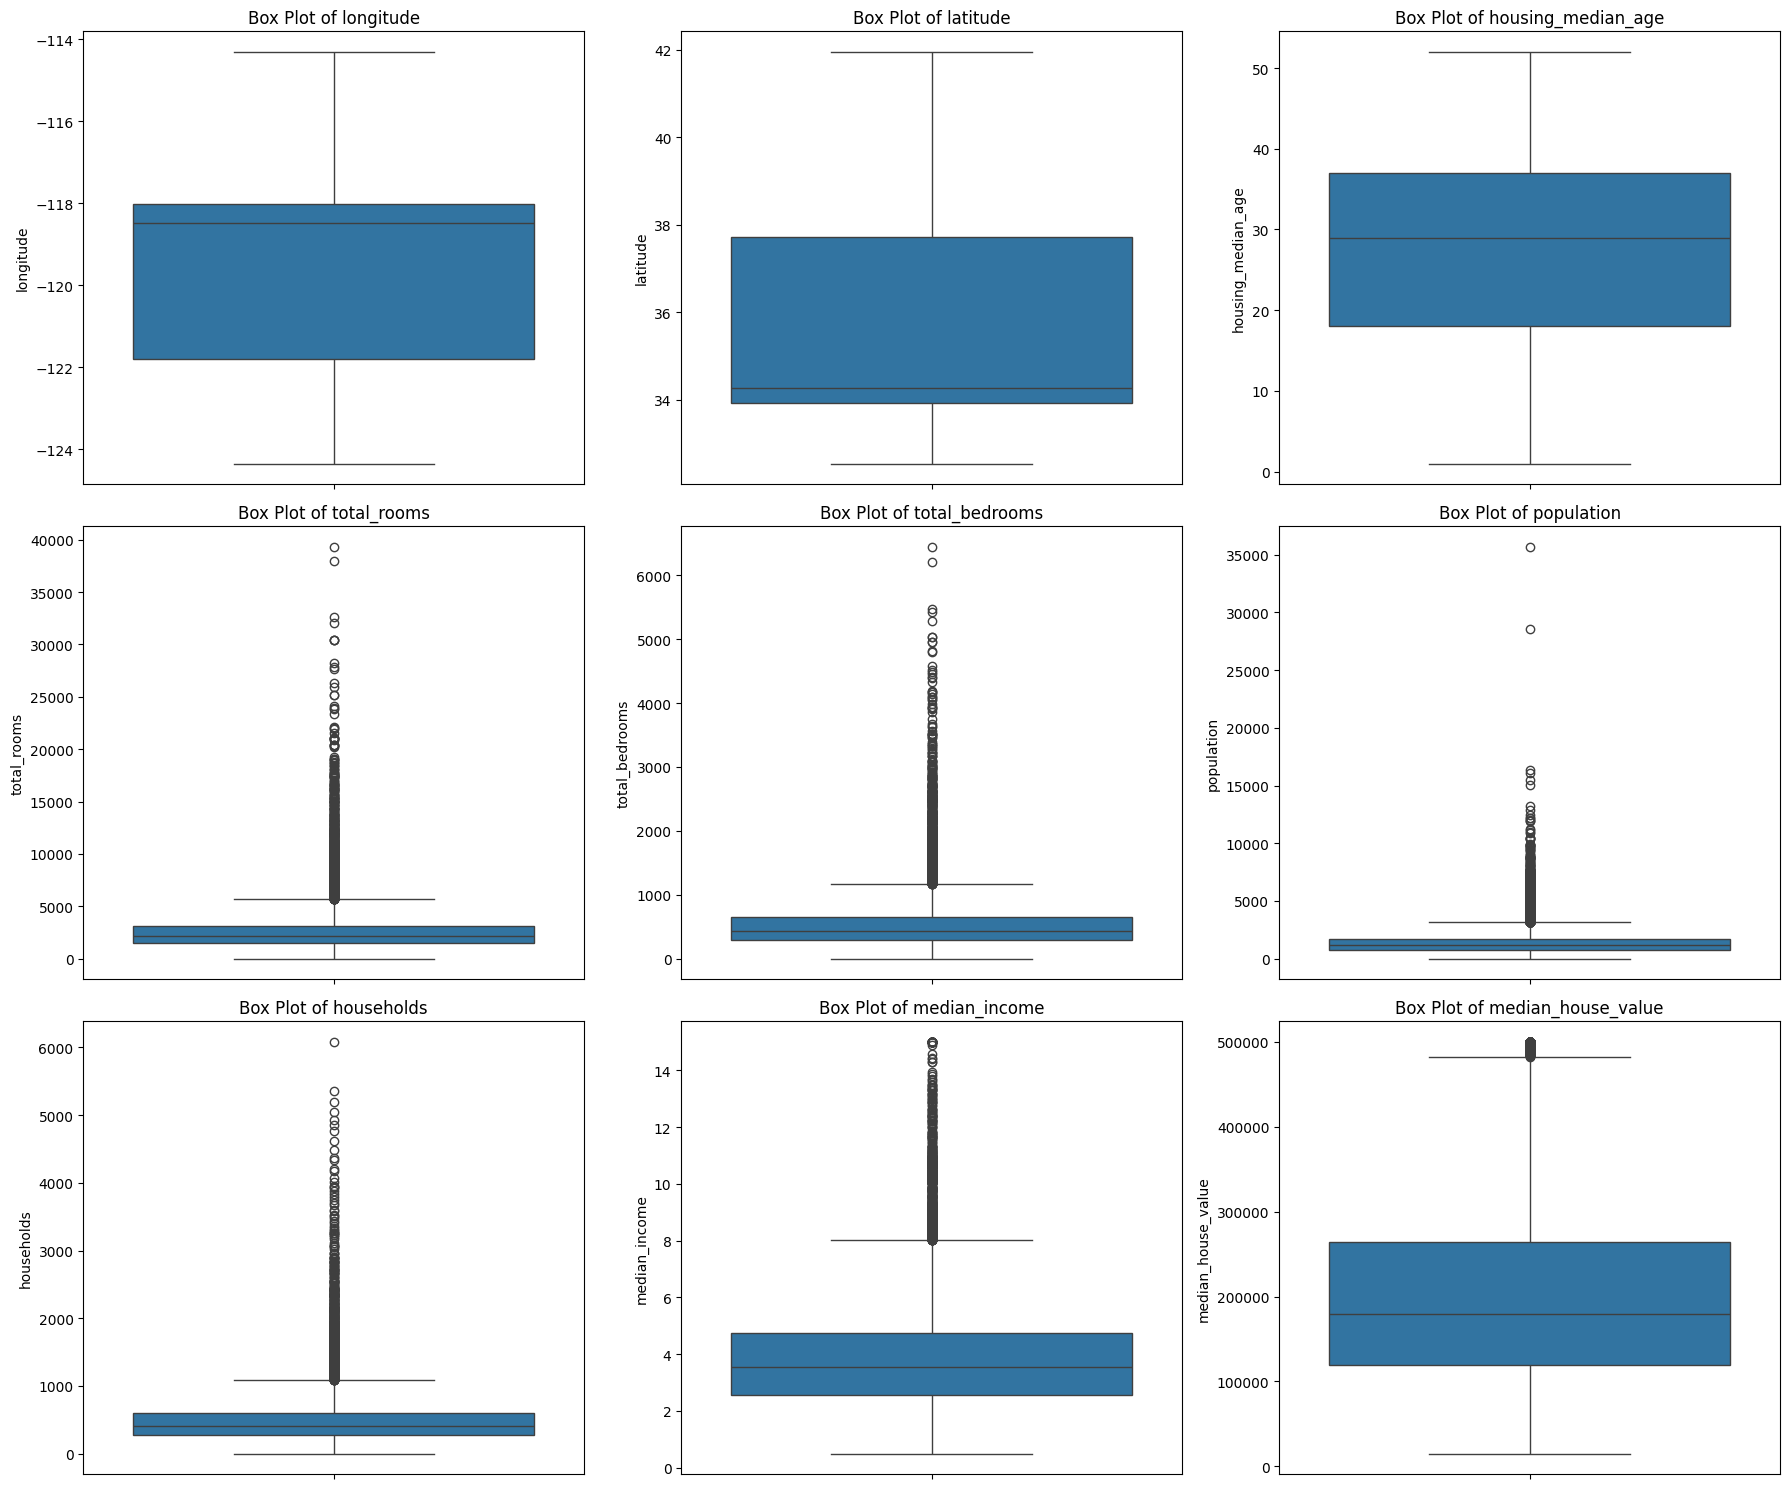

Box plots generated.


In [41]:
print("Box plots for numerical features to identify outliers")

numerical_cols = df.select_dtypes(include=np.number).columns

# Determine the number of rows and columns for the subplot grid
num_cols = 3
num_rows = int(np.ceil(len(numerical_cols) / num_cols))

plt.figure(figsize=(num_cols * 6, num_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
plt.show()
print("Box plots generated.")

**Impact of Data Capping**: The median_house_value specifically shows a prominent line of outliers at the maximum value ($500,001). This isn't necessarily a natural distribution but rather a consequence of the data being capped at this value during collection, which the histogram analysis also revealed. These aren't true extreme values in the sense of a natural distribution, but rather a truncation artifact.



To analyze the relationships between key numerical features and the target variable (`median_house_value`), scatter plots are the most suitable visualization.



In [42]:
# Exclude 'longitude' and 'latitude' from general histograms as they are geographical coordinates and their distributions are often
# best visualized differently (e.g., scatter plots with median_house_value or geographical plots).

Scatter plots for key numerical features against median_house_value


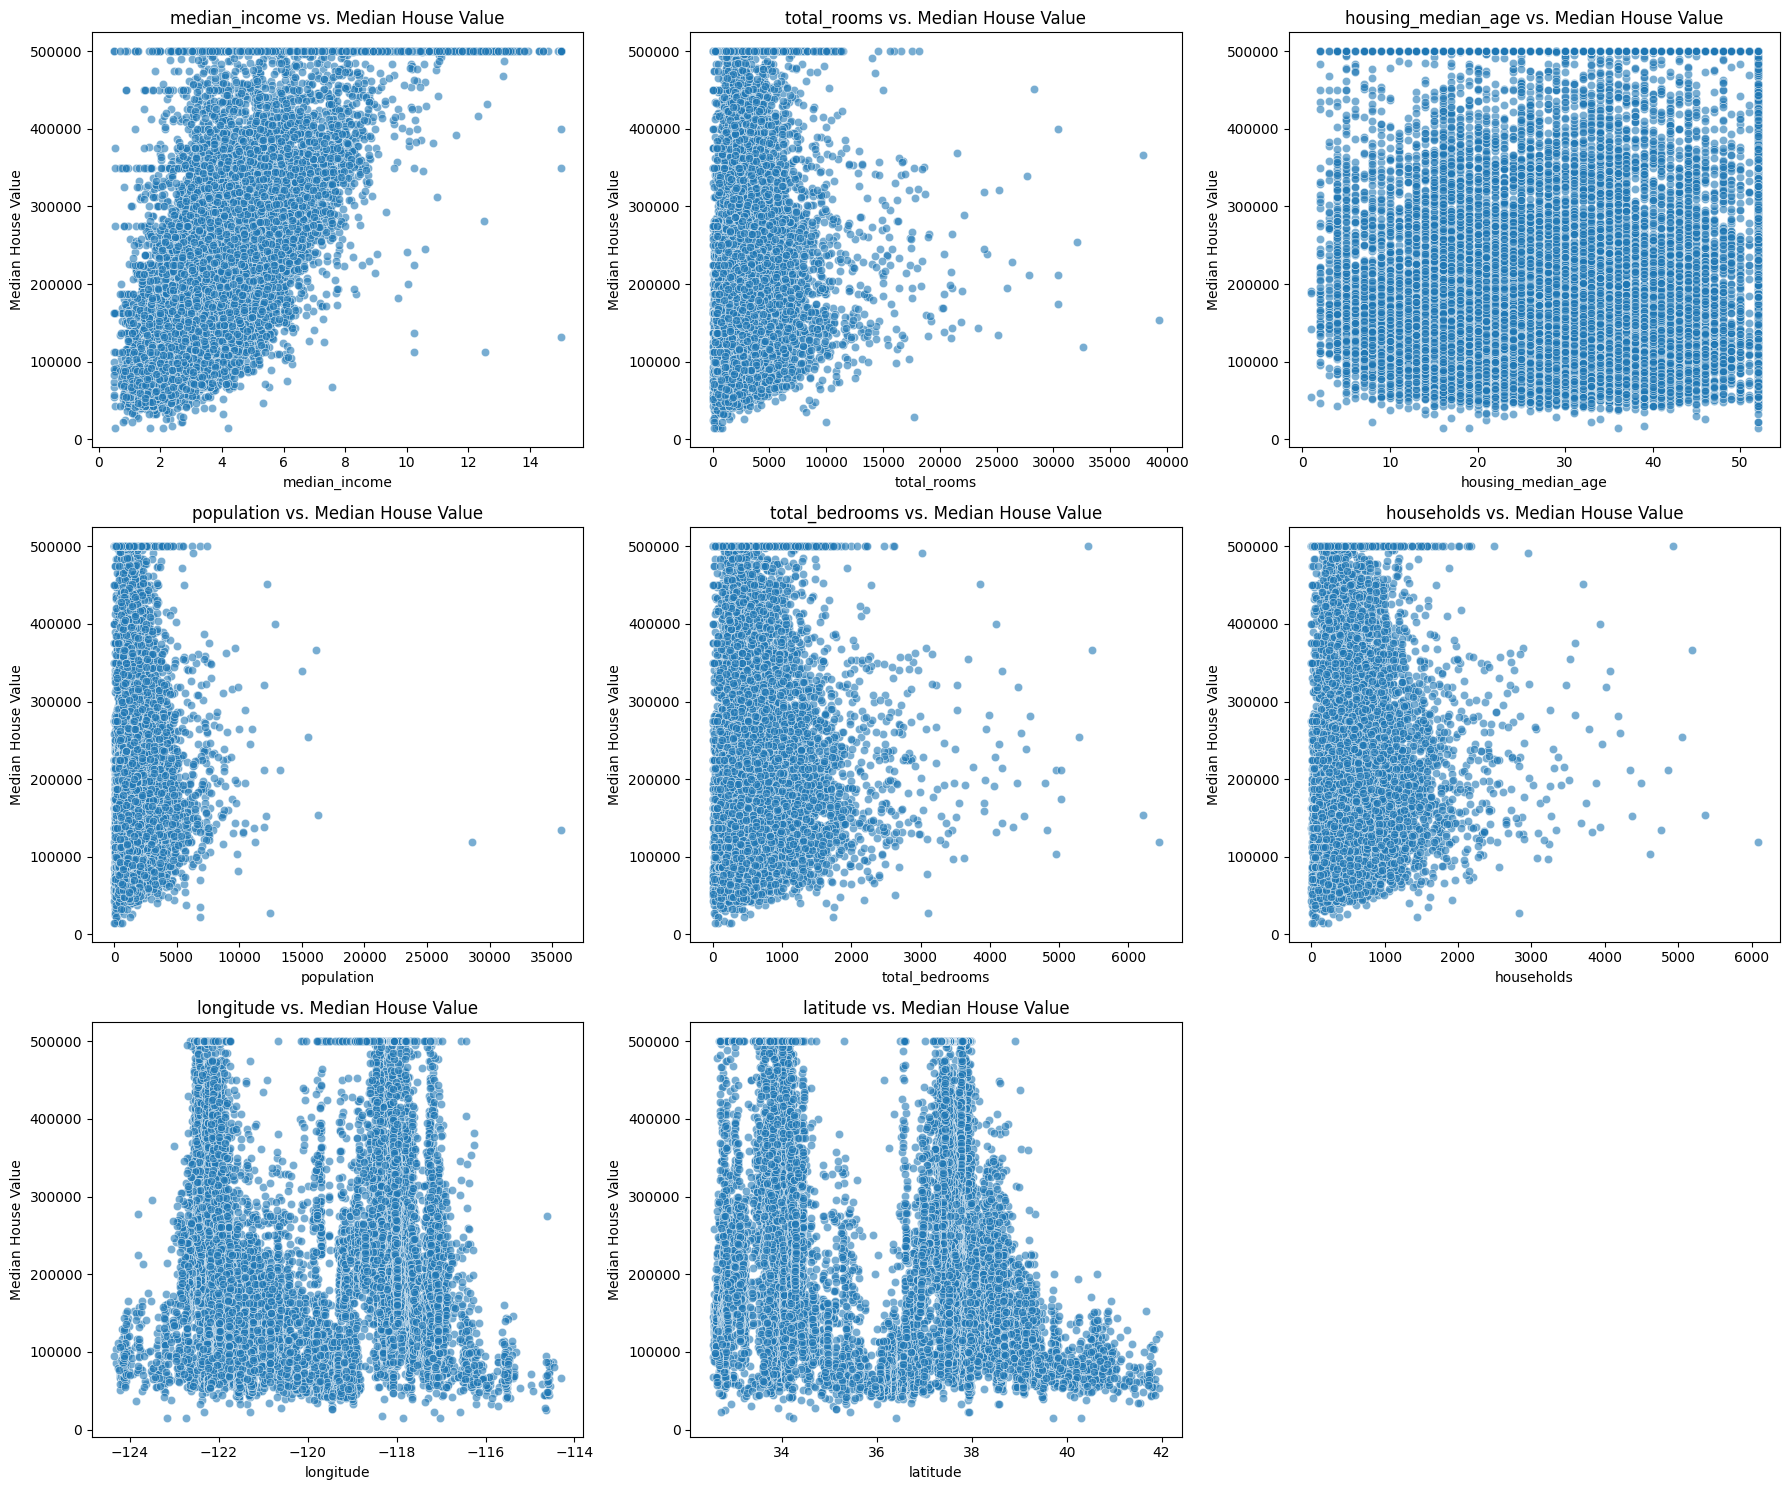

Scatter plots generated.


In [43]:
print("Scatter plots for key numerical features against median_house_value")

# Key numerical features identified as potentially important for prediction
key_features = ['median_income', 'total_rooms', 'housing_median_age', 'population', 'total_bedrooms', 'households', 'longitude', 'latitude']

# Determine the number of rows and columns for the subplot grid
num_cols = 3  # You can adjust this number
num_rows = int(np.ceil(len(key_features) / num_cols))

plt.figure(figsize=(num_cols * 6, num_rows * 5))
for i, col in enumerate(key_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=df[col], y=df['median_house_value'], alpha=0.6)
    plt.title(f'{col} vs. Median House Value')
    plt.xlabel(col)
    plt.ylabel('Median House Value')
    plt.tight_layout()
plt.show()
print("Scatter plots generated.")

Some key insights from scatter plots:

* **Strong Correlation of median_income**: The scatter plot of median_income against median_house_value clearly demonstrates a strong positive linear relationship, indicating that areas with higher median incomes tend to have significantly higher median house values.
* **Geographical Influence on Price**: The geographical distribution scatter plot (longitude vs. latitude, colored by median_house_value) visually confirms that location plays a crucial role in house pricing. There are distinct clusters of high-value properties in certain geographical regions, likely coastal or urban centers.
* **Improved Predictive Accuracy with Multiple Features**: Comparing the 'Actual vs. Predicted' scatter plots for Simple Linear Regression and Multiple Linear Regression, it's evident that the Multiple Linear Regression model provides more accurate predictions, with predicted values aligning much closer to the actual values along the diagonal line, especially for a broader range of house prices.

To understand the relationship between the categorical feature 'ocean_proximity' and the target variable 'median_house_value', a box plot or violin plot is suitable.



Box plot for 'ocean_proximity' against 'median_house_value'


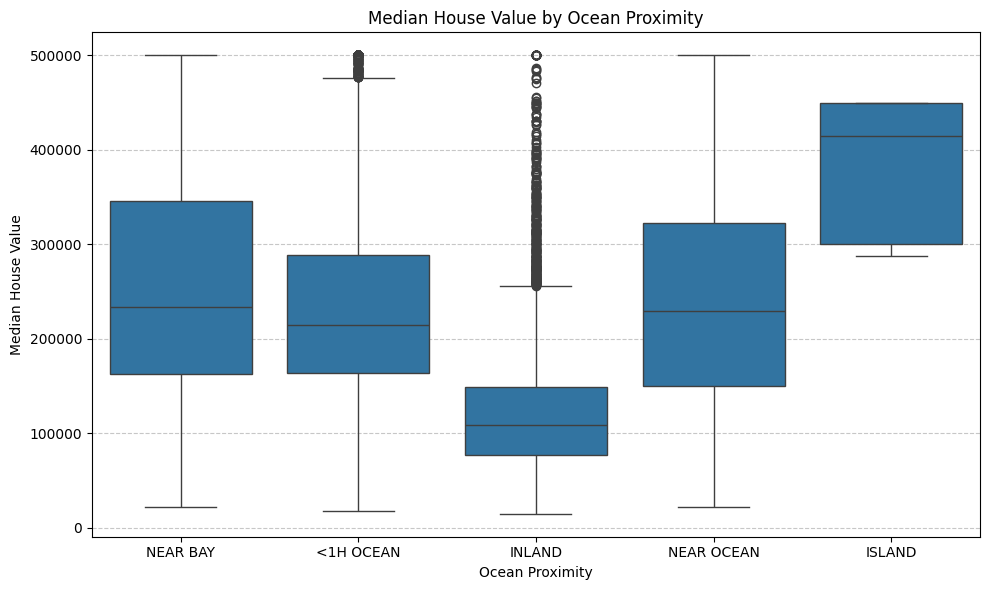

Box plot for 'ocean_proximity' generated.


In [44]:
print("Box plot for 'ocean_proximity' against 'median_house_value'")

plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.title('Median House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Box plot for 'ocean_proximity' generated.")

Some important points:

* **Outlier Identification**: Box plots are highly effective in visually identifying outliers, which are data points that fall outside the typical range (defined by the whiskers of the box plot). Many of our numerical features showed a considerable number of outliers, indicating extreme values present in the dataset.
* **Skewness Indication**: The position of the median within the box and the relative lengths of the whiskers can indicate the skewness of the distribution. For example, if the median is closer to the bottom of the box and the upper whisker is longer, it suggests a right-skewed distribution, which was observed in features like total_rooms and median_income.
* **Data Capping in median_house_value**: Specifically, the box plot for median_house_value highlighted a prominent line of outliers at the maximum value ($500,001). This isn't necessarily a natural distribution but rather a consequence of the data being capped at this value during collection, which also aligns with what was seen in the histograms. These are not true extreme values in the sense of a natural distribution, but rather an artifact of the data collection process.

To analyze the linear relationships between all numerical features, including with the target variable, a correlation matrix is essential.



Generating correlation matrix heatmap for numerical features...


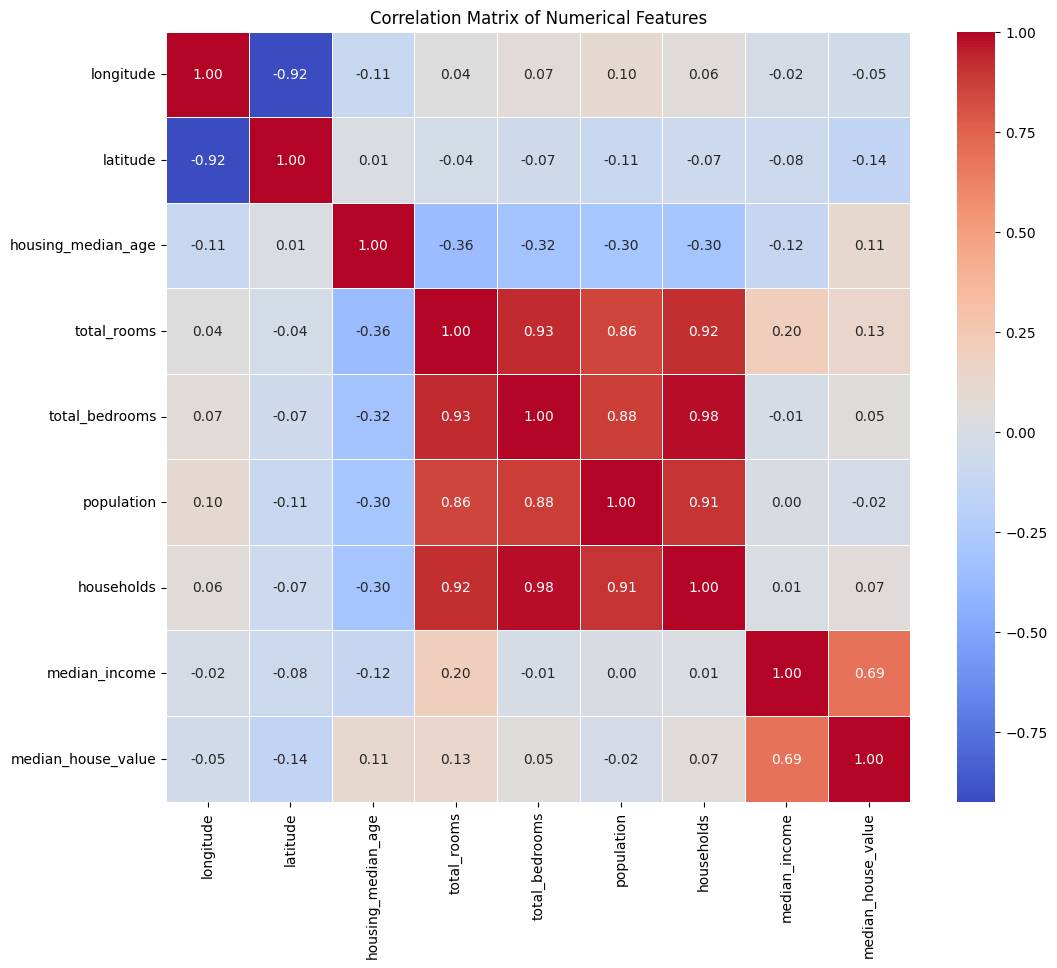

Correlation matrix heatmap generated.


In [45]:
print("Generating correlation matrix heatmap for numerical features...")

numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation matrix heatmap generated.")

Important points regarding correlations:

* **Strongest Positive Correlation with median_income**: The median_income feature shows the highest positive correlation with median_house_value (approximately 0.69). This indicates that as the median income in a district increases, the median house value tends to increase significantly.
* **Geographical Influence (longitude and latitude)**: latitude and longitude show moderate correlations with median_house_value. More interestingly, they are highly negatively correlated with each other (approximately -0.92), reflecting their geographical relationship. Their individual correlations with the target variable suggest that location is a significant factor in housing prices.
* **High Inter-feature Correlations**: Features like total_rooms, total_bedrooms, population, and households are highly positively correlated with each other (e.g., total_rooms and total_bedrooms have a correlation of about 0.93). This is expected, as a larger number of rooms usually implies more bedrooms, a larger population, and more households. While these are good predictors, their high inter-correlation could lead to multicollinearity in multiple linear regression models, which might need to be considered during model interpretation or selection of features for simpler models.

## Data Preprocessing and Preparation

## Handle Missing Values

Identify and address any missing values in the dataset. Choose an appropriate strategy for imputation (e.g., mean, median, mode) or decide whether to drop rows/columns, justifying the chosen approach. Document the changes made.


In [46]:
print("Checking for missing values in each column:")
print(df.isnull().sum())

Checking for missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Impute the missing values in the `total_bedrooms` column with its median, as it is a more robust choice for skewed distributions.



In [47]:
print("Imputing missing values in 'total_bedrooms' with the median...")
median_total_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_total_bedrooms)
print(f"Missing values in 'total_bedrooms' imputed with median: {median_total_bedrooms}")

Imputing missing values in 'total_bedrooms' with the median...
Missing values in 'total_bedrooms' imputed with median: 435.0


**Rechecking** To confirm that the imputation was successful and no missing values remain in `total_bedrooms`



In [48]:
print("Checking for remaining missing values after imputation:")
print(df.isnull().sum())

Checking for remaining missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Encode Categorical Features

Convert categorical variables, specifically 'ocean_proximity', into a numerical format suitable for machine learning models using techniques like one-hot encoding. Document the encoding strategy used.


**ONE HOT ENCODING**




In [49]:
# import the necessary `OneHotEncoder`
from sklearn.preprocessing import OneHotEncoder

print("OneHotEncoder imported successfully.")

OneHotEncoder imported successfully.


In [50]:
print("Applying One-Hot Encoding to 'ocean_proximity'")

# Instantiate OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'ocean_proximity' column
# Reshape to (-1, 1) because fit_transform expects a 2D array
ocean_proximity_encoded = encoder.fit_transform(df[['ocean_proximity']])

# Create a DataFrame from the encoded features with appropriate column names
ocean_proximity_df = pd.DataFrame(ocean_proximity_encoded, columns=encoder.get_feature_names_out(['ocean_proximity']))

# Reset index of df before concatenation to ensure proper alignment
df_reset = df.reset_index(drop=True)

# Concatenate the new one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df_reset, ocean_proximity_df], axis=1)

# Drop the original 'ocean_proximity' column
df = df.drop('ocean_proximity', axis=1)

print("One-Hot Encoding applied. Displaying the first 5 rows of the updated DataFrame:")
display(df.head())
print("Updated DataFrame info:")
df.info()

Applying One-Hot Encoding to 'ocean_proximity'
One-Hot Encoding applied. Displaying the first 5 rows of the updated DataFrame:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0


Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  int64  
 3   total_rooms                 20640 non-null  int64  
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  int64  
 6   households                  20640 non-null  int64  
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  int64  
 9   ocean_proximity_<1H OCEAN   20640 non-null  float64
 10  ocean_proximity_INLAND      20640 non-null  float64
 11  ocean_proximity_ISLAND      20640 non-null  float64
 12  ocean_proximity_NEAR BAY    20640 non-null  float64
 13  ocean_p

## Model development using:
<p><h3> 1. Simple Linear Regression
<p><h3> 2. Multiple Linear Regression

## Split Data into Training and Testing Sets

Divide the processed dataset into training and testing sets (e.g., 80% training, 20% testing) to ensure robust model evaluation and prevent overfitting. Set a random state for reproducibility.


* Separate the features (independent variables) from the target variable (`median_house_value`).
* Prepares the data for splitting into training and testing sets.



In [51]:
print("Separating features (X) and target (y)")
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Features (X) and target (y) separated successfully.")

Separating features (X) and target (y)
Features (X) and target (y) separated successfully.


In [52]:
# import the `train_test_split`
from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


In [53]:
print("Splitting data into training and testing sets")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Splitting data into training and testing sets
Data split successfully.
Shape of X_train: (16512, 13)
Shape of X_test: (4128, 13)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


## Feature Scaling

Apply feature scaling to numerical features to standardize their ranges. This step is crucial for many machine learning algorithms, including linear regression, to ensure that no single feature dominates the learning process due to its scale. We will use `StandardScaler` for this purpose.

In [54]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

print("StandardScaler imported successfully.")

StandardScaler imported successfully.


In [55]:
print("Applying feature scaling to numerical features...")

# Identify numerical columns to scale (excluding one-hot encoded and target variable)
# The 'ocean_proximity' encoded columns are already binary and don't need scaling in the same way.
# 'median_house_value' is the target variable.

numerical_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                      'total_bedrooms', 'population', 'households', 'median_income']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Numerical features scaled successfully.")

print("Displaying the first 5 rows of scaled X_train:")
display(X_train.head())

Applying feature scaling to numerical features...
Numerical features scaled successfully.
Displaying the first 5 rows of scaled X_train:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,0.0,0.0,0.0,0.0,1.0
8267,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,0.0,0.0,0.0,0.0,1.0
17445,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,0.0,0.0,0.0,0.0,1.0
14265,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,0.0,0.0,0.0,0.0,1.0
2271,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,0.0,1.0,0.0,0.0,0.0


## Visualize Geographical Impact on House Prices

To visualize the geographical impact of longitude and latitude on house prices, we will create a scatter plot using the original DataFrame. Longitude and latitude will define the position, and `median_house_value` will be represented by color, allowing us to observe patterns in house prices across different locations.

Visualizing geographical impact of longitude and latitude on house prices...


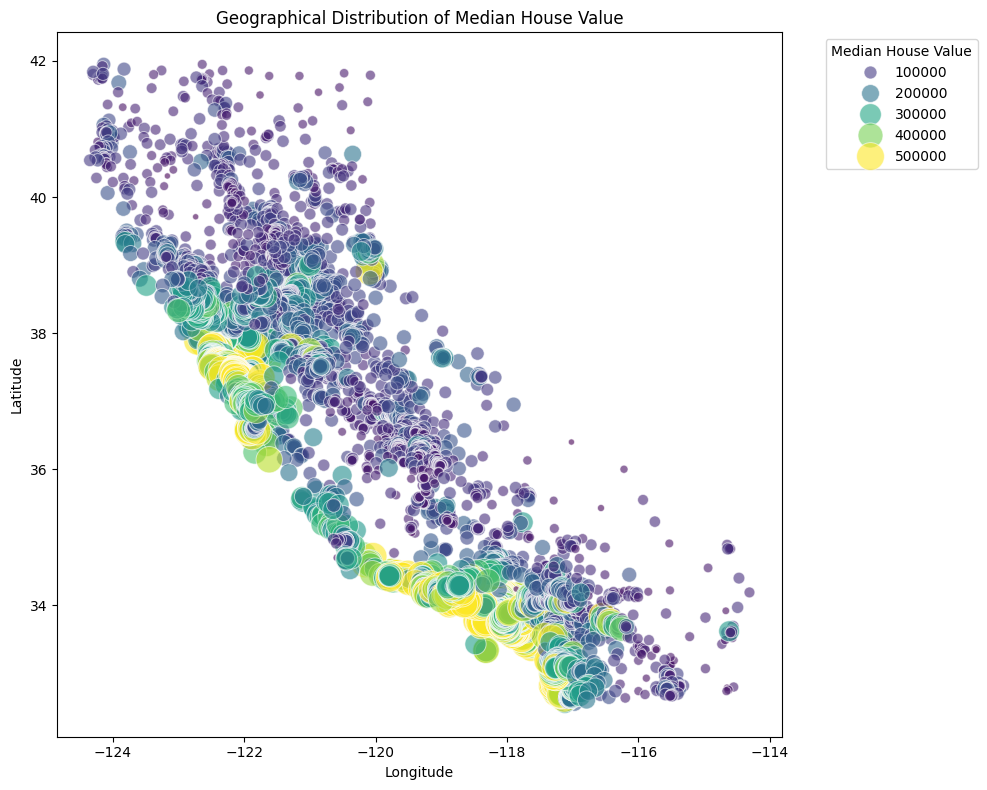

Geographical visualization generated.


In [56]:
print("Visualizing geographical impact of longitude and latitude on house prices...")

plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='median_house_value',
                size='median_house_value', sizes=(20, 400), alpha=0.6,
                palette='viridis', data=df)
plt.title('Geographical Distribution of Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Median House Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Geographical visualization generated.")

 Insights regarding geographical clusters of high-value properties:

* **Coastal Concentration**: It is evident that many of the high-value properties (represented by brighter colors and larger markers) are concentrated along the coast, particularly in Southern California.
* **Bay Area Influence**: There's also a noticeable cluster of high-value properties around the Bay Area (near San Francisco), as indicated by the higher median_house_value in that region.
Inland vs. Coastal Divide: Properties further inland generally show lower median house values, with a clear distinction between the higher values near the ocean and the lower values in the interior.
* **Specific Hotspots**: Within these general regions, there are specific, smaller clusters that stand out as having particularly high median house values, suggesting local factors like amenities, development, or exclusivity playing a role.

## Develop Simple Linear Regression Model

Build a Simple Linear Regression model using one of the most correlated features with 'median_house_value' as the independent variable. Train the model on the training data.


In [57]:
# Import the LinearRegression model from sklearn
from sklearn.linear_model import LinearRegression

print("LinearRegression imported successfully.")

LinearRegression imported successfully.


Select 'median_income' as the independent variable, reshape it, instantiate a `LinearRegression` model, and then train the model using `X_train` and `y_train`.



In [58]:
print("Building and training Simple Linear Regression model...")

# Select 'median_income' as the independent variable and reshape it
X_train_slr = X_train[['median_income']].values.reshape(-1, 1)
X_test_slr = X_test[['median_income']].values.reshape(-1, 1)

# Instantiate LinearRegression model
slr_model = LinearRegression()

# Train the model
slr_model.fit(X_train_slr, y_train)

print("Simple Linear Regression model trained successfully.")
print(f"Intercept: {slr_model.intercept_}")
print(f"Coefficient (median_income): {slr_model.coef_[0]}")

Building and training Simple Linear Regression model...
Simple Linear Regression model trained successfully.
Intercept: 207194.6937378876
Coefficient (median_income): 79851.9564426035


## Develop Multiple Linear Regression Model

Build a Multiple Linear Regression model using several relevant features (e.g., 'median_income', 'total_rooms', 'housing_median_age', geographical coordinates, and encoded 'ocean_proximity').
Train the model on the training data.


Build a `LinearRegression` model for multiple linear regression, train it using the entire `X_train` and `y_train` datasets, and then print the intercept and coefficients of the trained model.



In [59]:
print("Building and training Multiple Linear Regression model")

# Instantiate LinearRegression model
mlr_model = LinearRegression()

# Train the model using the entire X_train and y_train datasets
mlr_model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully.")
print(f"Intercept: {mlr_model.intercept_}")
print("Coefficients:")
# Create a DataFrame for better readability of coefficients
coefficients_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': mlr_model.coef_})
print(coefficients_df)

Building and training Multiple Linear Regression model
Multiple Linear Regression model trained successfully.
Intercept: 238826.35944525112
Coefficients:
                       Feature    Coefficient
0                    longitude  -53826.648016
1                     latitude  -54415.696144
2           housing_median_age   13889.866189
3                  total_rooms  -13094.251162
4               total_bedrooms   43068.181842
5                   population  -43403.432427
6                   households   18382.196324
7                median_income   75167.774766
8    ocean_proximity_<1H OCEAN  -18926.582862
9       ocean_proximity_INLAND  -58713.239023
10      ocean_proximity_ISLAND  117198.489753
11    ocean_proximity_NEAR BAY  -24063.225079
12  ocean_proximity_NEAR OCEAN  -15495.442789


## Evaluate Models both Simple and Mutiple Linear Regression models
Evaluate the performance of both the Simple and Multiple Linear Regression models on the test set. Calculate and report key regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared for each model. Compare the performance of the two models based on these metrics.


The first two instructions are to make predictions on the test set for both Simple and Multiple Linear Regression models. I will create a code block to achieve this, making predictions for `slr_model` using `X_test_slr` and for `mlr_model` using `X_test`.



In [60]:
print("Making predictions on the test set for Simple Linear Regression model...")
y_pred_slr = slr_model.predict(X_test_slr)

print("Making predictions on the test set for Multiple Linear Regression model...")
y_pred_mlr = mlr_model.predict(X_test)

print("Predictions made successfully.")

Making predictions on the test set for Simple Linear Regression model...
Making predictions on the test set for Multiple Linear Regression model...
Predictions made successfully.


In [61]:
#  Import the necessary evaluation metrics like `mean_squared_error`, `r2_score`
from sklearn.metrics import mean_squared_error, r2_score

print("mean_squared_error, r2_score, and numpy imported successfully.")

mean_squared_error, r2_score, and numpy imported successfully.


 Calculate the MSE, RMSE, and R-squared for both Simple and Multiple Linear Regression models and then print these metrics for comparison.



In [62]:
print("Evaluating Simple Linear Regression Model...")
# Calculate metrics for Simple Linear Regression
mse_slr = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test, y_pred_slr)

print(f"Simple Linear Regression Metrics:")
print(f"  Mean Squared Error (MSE): {mse_slr:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_slr:.2f}")
print(f"  R-squared (R2): {r2_slr:.2f}")

print("\nEvaluating Multiple Linear Regression Model...")
# Calculate metrics for Multiple Linear Regression
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print(f"Multiple Linear Regression Metrics:")
print(f"  Mean Squared Error (MSE): {mse_mlr:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_mlr:.2f}")
print(f"  R-squared (R2): {r2_mlr:.2f}")


Evaluating Simple Linear Regression Model...
Simple Linear Regression Metrics:
  Mean Squared Error (MSE): 7091157771.77
  Root Mean Squared Error (RMSE): 84209.01
  R-squared (R2): 0.46

Evaluating Multiple Linear Regression Model...
Multiple Linear Regression Metrics:
  Mean Squared Error (MSE): 4908476721.16
  Root Mean Squared Error (RMSE): 70060.52
  R-squared (R2): 0.63


## Visualize Model Performance

Create visualizations to illustrate the performance of the models, including scatter plots of actual vs. predicted values and residual plots for both Simple and Multiple Linear Regression models.


### Scatter plot of actual vs. predicted values for the Simple Linear Regression model

Scatter plot for Simple Linear Regression: Actual vs. Predicted


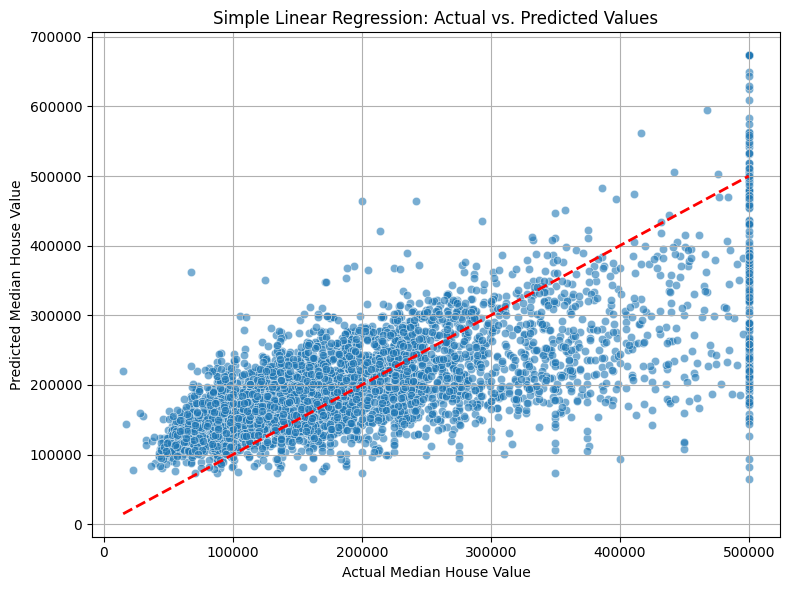

Scatter plot for Simple Linear Regression generated.


In [63]:
print("Scatter plot for Simple Linear Regression: Actual vs. Predicted")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_slr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line for perfect prediction
plt.title('Simple Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Scatter plot for Simple Linear Regression generated.")

Residual plot for the Simple Linear Regression model.
 * It will helps to check the assumptions of linearity, homoscedasticity, and independence of errors.
 * I will plot the predicted values against the residuals and add a horizontal line at y=0.



Residual plot for Simple Linear Regression


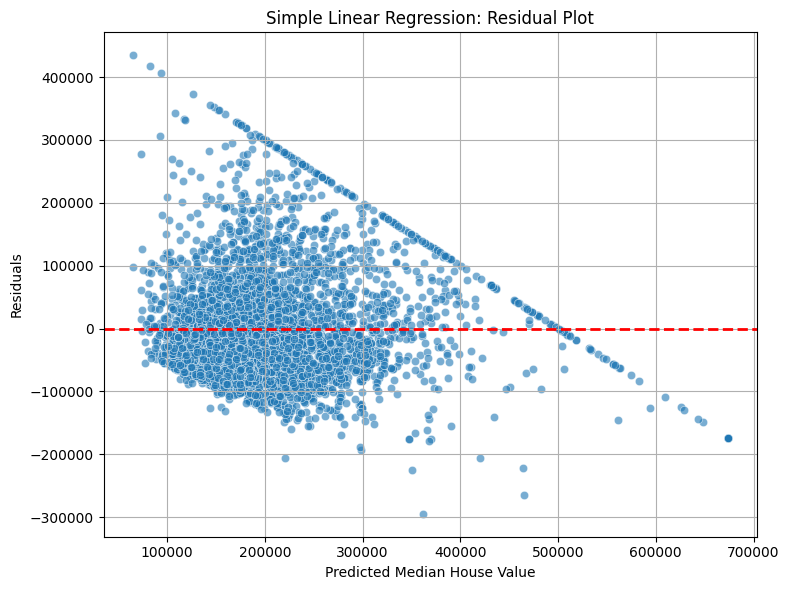

Residual plot for Simple Linear Regression generated.


In [64]:
print("Residual plot for Simple Linear Regression")

residuals_slr = y_test - y_pred_slr

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_slr, y=residuals_slr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Horizontal line at y=0
plt.title('Simple Linear Regression: Residual Plot')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Residual plot for Simple Linear Regression generated.")

### Scatter plot of actual vs. predicted values for the Multiple Linear Regression model

Scatter plot for Multiple Linear Regression: Actual vs. Predicted


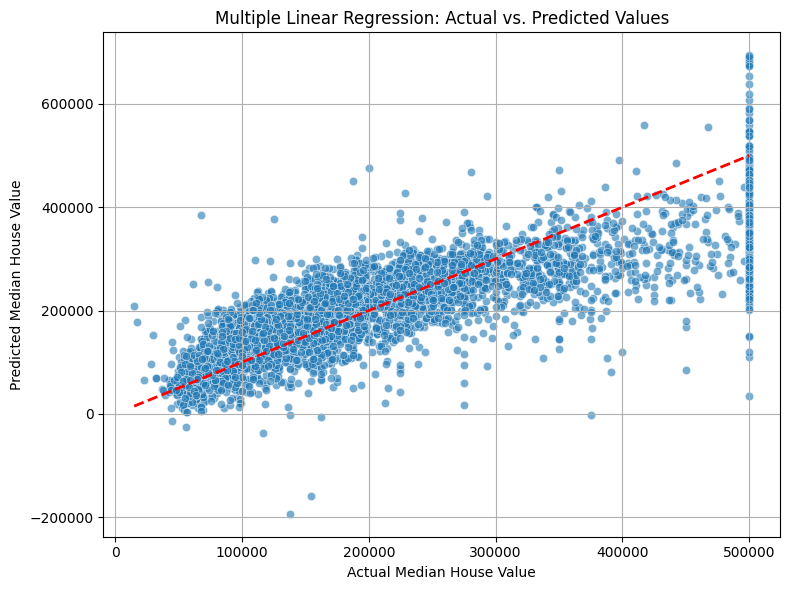

Scatter plot for Multiple Linear Regression generated.


In [65]:
print("Scatter plot for Multiple Linear Regression: Actual vs. Predicted")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_mlr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line for perfect prediction
plt.title('Multiple Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Scatter plot for Multiple Linear Regression generated.")

Residual plot for the Multiple Linear Regression model.
*  Check the assumptions of linearity, homoscedasticity, and independence of errors for the multiple linear regression model.
* I will plot the predicted values against the residuals and add a horizontal line at y=0, as specified in instruction 4 of the subtask.



Residual plot for Multiple Linear Regression


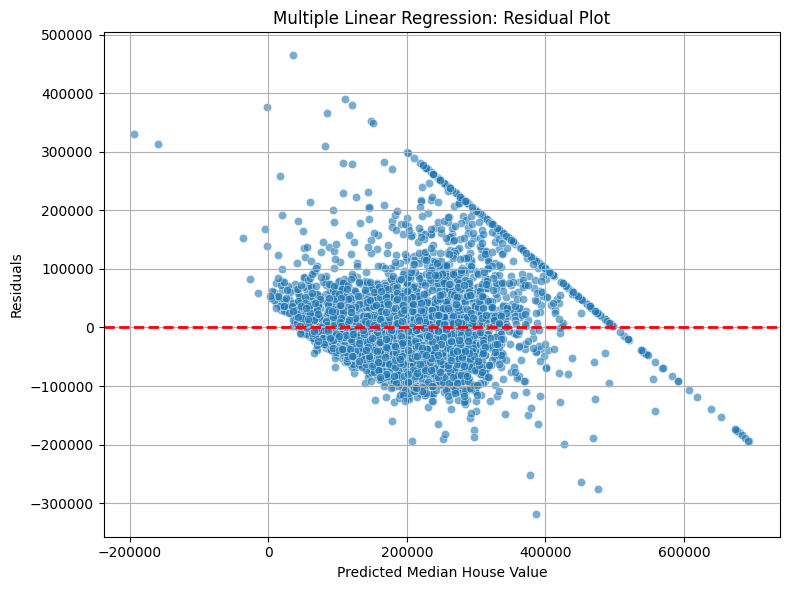

Residual plot for Multiple Linear Regression generated.


In [66]:
print("Residual plot for Multiple Linear Regression")

residuals_mlr = y_test - y_pred_mlr

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_mlr, y=residuals_mlr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Horizontal line at y=0
plt.title('Multiple Linear Regression: Residual Plot')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Residual plot for Multiple Linear Regression generated.")

## Summary:

### Data Analysis Key Findings

*   **Data Overview and Missing Values**: The dataset contains 20,640 entries and 10 columns. The `total_bedrooms` column initially had 207 missing values, which were successfully imputed using the median value of 435.0. All other columns were complete.
*   **Data Distribution and Outliers**:
    *   Most numerical features, including `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, and `median_house_value`, exhibited right-skewed distributions.
    *   A significant ceiling effect was observed for `median_house_value` at $500,001, indicating potential data truncation. Box plots confirmed the presence of numerous outliers in several numerical features.
*   **Feature Relationships**:
    *   `median_income` showed the strongest positive linear correlation with `median_house_value` (approximately 0.69).
    *   `ocean_proximity` significantly influenced `median_house_value`, with 'ISLAND', 'NEAR BAY', and '<1H OCEAN' properties generally having higher values than 'INLAND' properties.

    *   Geographical coordinates (`longitude` and `latitude`) also showed correlations, indicating regional variations in house values.
*   **Categorical Feature Encoding**: The `ocean_proximity` categorical feature was successfully converted into numerical format using one-hot encoding, creating five new binary features.
*   **Model Performance Comparison**:
    *   **Simple Linear Regression (SLR)**: Using `median_income` as the sole predictor, the SLR model achieved an R-squared of 0.46, an MSE of 7,091,157,771.77, and an RMSE of 84,209.01.
    *   **Multiple Linear Regression (MLR)**: Incorporating multiple features, including `median_income`, geographical coordinates, `housing_median_age`, and one-hot encoded `ocean_proximity`, the MLR model significantly improved performance with an R-squared of 0.63, an MSE of 4,908,476,721.16, and an RMSE of 70,060.52.
*   **Model Coefficients**: The MLR model indicated that `median_income` has a  
    strong positive influence ($39,473.98 coefficient), while `ocean_proximity_ISLAND` has a very high positive impact ($117,198.49 coefficient), and `ocean_proximity_INLAND` a strong negative impact ($-58,713.24 coefficient) on `median_house_value`.

    *   **Intercept**: This is the predicted `median_house_value` when all other features are zero. In a real-world context, a zero value for many of these features (like income or rooms) might not be meaningful, so it's often best understood as the baseline value.

    *   **`longitude` (-53826.65)**: For every one unit increase in `longitude` (moving east), the `median_house_value` is predicted to decrease by approximately $53,826.65, assuming all other variables remain constant.

    *   **`latitude` (-54415.70)**: For every one unit increase in `latitude` (moving north), the `median_house_value` is predicted to decrease by approximately $54,415.70, assuming all other variables remain constant. Together, longitude and latitude indicate the strong geographical influence on house prices.

    *   **`housing_median_age` (13889.87)**: For every one year increase in the median age of houses, the `median_house_value` is predicted to increase by approximately $13,889.87, holding all other features constant.

    *   **`total_rooms` (-13094.25)**: For every one unit increase in `total_rooms`, the `median_house_value` is predicted to decrease by approximately $13,094.25. This might seem counter-intuitive, but it's important to remember that these are scaled features and their interpretation needs to be careful in the presence of other correlated features like `total_bedrooms` or `households`.

    *   **`total_bedrooms` (43068.18)**: For every one unit increase in `total_bedrooms`, the `median_house_value` is predicted to increase by approximately $43,068.18, all else being equal.

    *   **`population` (-43403.43)**: For every one unit increase in `population`, the `median_house_value` is predicted to decrease by approximately $43,403.43. Similar to `total_rooms`, this could be influenced by other factors and scaling.

    *   **`households` (18382.20)**: For every one unit increase in `households`, the `median_house_value` is predicted to increase by approximately $18,382.20, all else being equal.

    *   **`median_income` (75167.77)**: This is one of the strongest positive predictors. For every one unit increase in `median_income`, the `median_house_value` is predicted to increase by a substantial $75,167.77, holding all other features constant. This confirms its strong correlation seen in EDA.

    *   **`ocean_proximity_<1H OCEAN` (-18926.58)**: If a property is within '<1H OCEAN' proximity (compared to the baseline category, which is implicitly dropped by one-hot encoding to avoid multicollinearity), its `median_house_value` is predicted to be about $18,926.58 lower.

    *   **`ocean_proximity_INLAND` (-58713.24)**: Being an 'INLAND' property significantly reduces the `median_house_value` by approximately $58,713.24 compared to the baseline.

    *   **`ocean_proximity_ISLAND` (117198.49)**: Properties on 'ISLAND' are predicted to have a much higher `median_house_value`, increasing it by approximately $117,198.49 compared to the baseline, making it the feature with the largest positive coefficient.

    *   **`ocean_proximity_NEAR BAY` (-24063.23)**: 'NEAR BAY' properties are predicted to have a `median_house_value` lower by about $24,063.23 compared to the baseline.

    *   **`ocean_proximity_NEAR OCEAN` (-15495.44)**: 'NEAR OCEAN' properties are predicted to have a `median_house_value` lower by about $15,495.44 compared to the baseline.



### Insights or Next Steps

*   **Model Selection**: The Multiple Linear Regression model is clearly superior to the Simple Linear Regression model for predicting `median_house_value` due to its lower error metrics (MSE, RMSE) and higher explanatory power (R-squared). Therefore, the MLR model is recommended for this prediction task.
*   **Further Model Improvement**: Explore advanced regression techniques (e.g., polynomial regression, decision tree regressors, ensemble methods) or incorporate feature engineering (e.g., creating interaction terms, transforming skewed features like `median_house_value` to address the ceiling effect) to potentially further improve predictive accuracy.